# Markov Model Monte Carlo Demo

In [1]:
import numpy as np
import emcee
import matplotlib.pyplot as plt
from corner import corner

## Mock Data:
The mock data uses a simplified scenario and assumes we are observing stars from a telescope. It has 3 columns:
- `time_days`: the day the telescope observed the star
- `rv_m_s`: measured velocity of the star (+ → moving towards us, - → moving away)
- `rv_err`: measure of uncertainty / error from telescope

In [2]:
# Load the mock data
data = np.genfromtxt('mcmc-mock-data.csv', delimiter=',', skip_header=1)
t = data[:, 0]       # Time (days)
rv_data = data[:, 1] # Radial Velocity (m/s)
rv_err = data[:, 2]  # Telescope Error (m/s)

## Implementation + Explanation:

### MCMC Overview:

- Think of MCMC like dropping a number of "hikers" (aka walkers) into a mountain range. The objective is to find the highest peak. 

- The "elevation" of the peak = the likelihood / how well the combination of [Period, Amplitude, Velocity_Shift] matches the CSV data.

- The walkers use a collective hill climbing algo to find the highest peak. 

### Description of Functions (below):

- `rv_model`: this is the **Forward Model** which draws a wave with the guess values for Period, Amplitude  and Velocity_Shift
    - Period → wave width
    - Amplitude → wave height
    - Velocity_Shift (aka Gamma) → y-intercept

- `log_likelihood`: Takes the "guessed" wave (made by function above) and compares it to the actual data points. High score = close to 0, more error = higher log likelihood

- `log_prior`: Rejects guesses that aren't physically possible

- `log_probability`: Combination of the above functions; returns `log_prior` + `log_likelihood`. This is the "total score"



In [ ]:
# Physics Model / "Forward Model"
# theta the guess of: [Period, Amplitude, Velocity_Shift]
def rv_model(theta, t):
    P, K, gamma = theta
    return gamma + K * np.sin(2 * np.pi * t / P)

def log_likelihood(theta, t, rv_data, rv_err):
    model = rv_model(theta, t)
    chi2 = np.sum(((rv_data - model) / rv_err) ** 2)
    return -0.5 * chi2

def log_prior(theta):
    P, K, gamma = theta
    # allow reasonable guesses
    if 0.1 < P < 100.0 and 0.0 < K < 50.0 and -50.0 < gamma < 50.0:
        return 0.0
    # If the guesses break physics, return -inf to reject
    return -np.inf

def log_probability(theta, t, rv_data, rv_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    # final score is the Prior + the Likelihood
    return lp + log_likelihood(theta, t, rv_data, rv_err)

## Run the MCMC Algo:

In [ ]:
guess = [40.0, 10.0, 5.0] # random starting guess: [P, K, gamma]
nwalkers = 32
ndim = 3 # number of params to find

# Scatter the 32 walkers in a tight ball around our initial guess
pos = guess + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(t, rv_data, rv_err))

print("Running MCMC...")
sampler.run_mcmc(pos, 5000) # for 5000 steps
print("Done!")

Running MCMC...
Done!


## Visualization:

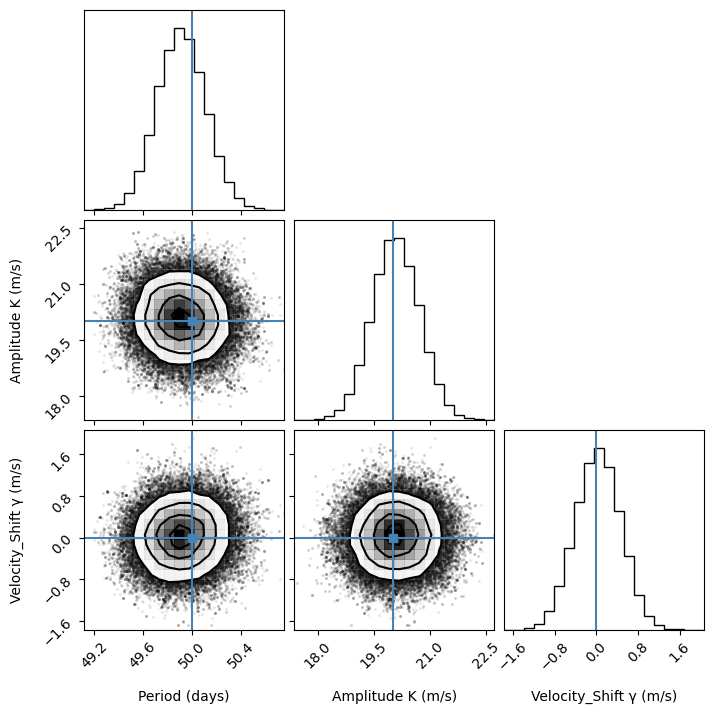

In [23]:
# Discard the first 1000 steps (discovery phase)
samples = sampler.get_chain(discard=1000, flat=True)

fig = corner(
    samples, 
    labels=["Period (days)", "Amplitude K (m/s)", "Velocity_Shift γ (m/s)"],
    truths=[50.0, 20.0, 0.0]  # true value used to make mock data
)
plt.show()

### Interpretation:
- **Blue lines / dots indicate true values**
- Each graph is a comparison between the **y-axis parameter** and the **x-axis parameter**. The target-shaped graphs compare 2 parameters so are 2D, whereas the bell curve graphs are 1D as they compare one parameter.

- The **target-shaped graphs represent** a bird's view "looking down" at the mountain peak. It shows how 2 parameters interact with each other. The darkest spot (bullseye) is the most likely combination of both parameters.
- The bell curves represent a "slice" of the bullseye along the vertical axis and shows the final probability for that one parameter.
    - Center of curve = highest probability guess for parameter
    - Width of the curve = margin of error





## Final Results:

In [22]:
import numpy as np
from IPython.display import display, Markdown

# The names of our 3 parameters
labels = ["Period (days)", "Amplitude K (m/s)", "Velocity_Shift γ (m/s)"]

print("🎯 MCMC FINAL RESULTS:")
print("-" * 30)

for i in range(3):
    all_guesses = samples[:, i]
    
    # 50th percentile = middle of hill
    best_guess = np.percentile(all_guesses, 50)
    
    print(f"{labels[i]:<18}: {best_guess:>6.2f}")

🎯 MCMC FINAL RESULTS:
------------------------------
Period (days)     :  49.92
Amplitude K (m/s) :  20.08
Velocity_Shift γ (m/s):   0.03


## Moving Forward:

With our real Gaia data, MCMC will shift from fitting a wave to predicting the actual physical traits of the system. We will use it to calculate:

- Mass of the Primary Star (M1​)

- Mass of the Companion (M2​): This is our core metric for classification (ex: <13 Jupiter masses = Exoplanet).

- Inclination / Tilt (i): We must calculate the orbital tilt to break the "face-on vs. edge-on" ambiguity; without it, a massive star on a tilted orbit looks like a small planet.